In [28]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

In [39]:
data4 = r"C:\Users\rajeshkumar.t\Desktop\ML\Time_series.csv"
df1= pd.read_csv(data4)
print(df.head(2))
df =df1[df1['total_orders'] >1000000].copy()

           ds  total_orders  total_revenue     lag_1  lag_7  log_orders  \
34 2026-01-03        100213    100247686.0       NaN    NaN   11.515053   
55 2026-01-04        132428    137049827.0  100213.0    NaN   11.793794   

    trend_index  lag_1_log  rolling_mean_3  
34            0        NaN             NaN  
55            1  11.515053             NaN  


In [40]:
df_summary = df.groupby('ds').agg({
    'total_orders': 'sum',
    'total_revenue': 'mean'
}).reset_index()
print(df_summary)
    

            ds  total_orders  total_revenue
0   2026-01-10       1218009   7.942728e+08
1   2026-01-11       1739881   1.067655e+09
2   2026-01-12       2336536   1.434672e+09
3   2026-01-13       2669570   1.906774e+09
4   2026-01-14       3004763   2.123662e+09
..         ...           ...            ...
92  2026-04-12       6426756   5.818228e+09
93  2026-04-13       5547380   5.175332e+09
94  2026-04-14       5684169   5.690870e+09
95  2026-04-15       5384877   6.783072e+09
96  2026-04-16       5622518   7.359522e+09

[97 rows x 3 columns]


In [41]:
df['ds'] = df['ds'].astype("datetime64[ns]")

In [42]:
df = df.sort_values('ds')

In [43]:
df['lag_1'] =df['total_orders'].shift(1)
df['lag_7'] = df['total_orders'].shift(7)
df_clean = df.dropna()

In [44]:
X= df_clean[['lag_1', 'lag_7']]
y=df_clean['total_orders']
split =int(len(df_clean) *0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
model =LinearRegression()
model.fit(X_train,y_train)
df_clean['forecast'] = model.predict(X)

print(df_clean[['ds', 'total_orders', 'forecast']].head(10))

            ds  total_orders      forecast
74  2026-01-17       6296898  5.445961e+06
28  2026-01-18       6174636  6.128096e+06
92  2026-01-19       5601681  6.033119e+06
51  2026-01-20       5537168  5.660195e+06
17  2026-01-21       5347983  5.609482e+06
8   2026-01-22       5512228  5.473588e+06
101 2026-01-23       4532017  5.529455e+06
75  2026-01-24       4859402  4.875912e+06
37  2026-01-25       5133105  5.087007e+06
80  2026-01-26       5356616  5.277280e+06


In [45]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression


In [46]:
df['log_orders'] =np.log(df['total_orders'])
df['trend_index'] = np.arange(len(df))
df['lag_1_log'] =df['log_orders'].shift(1)
df['rolling_mean_3'] = df['log_orders'].shift(1).rolling(window=3).mean()
df_clean = df.dropna()

X= df_clean[['trend_index', 'lag_1_log', 'rolling_mean_3']]
y=df_clean['log_orders']
model= LinearRegression()
model.fit(X,y)
df_clean['log_forecast'] = model.predict(X)
df_clean['correct_forecast'] = np.exp(df_clean['log_forecast'])
print(df_clean[['ds', 'total_orders', 'correct_forecast']])

           ds  total_orders  correct_forecast
74 2026-01-17       6296898      5.589423e+06
28 2026-01-18       6174636      6.153506e+06
92 2026-01-19       5601681      5.841616e+06
51 2026-01-20       5537168      5.400187e+06
17 2026-01-21       5347983      5.402763e+06
..        ...           ...               ...
71 2026-04-12       6426756      6.043367e+06
12 2026-04-13       5547380      6.231559e+06
16 2026-04-14       5684169      5.603174e+06
20 2026-04-15       5384877      5.741782e+06
48 2026-04-16       5622518      5.580238e+06

[90 rows x 3 columns]


In [47]:
def mape(actual, pred):
    return np.mean(np.abs((actual- pred)/actual) )* 100
error = mape(df_clean['total_orders'], df_clean['correct_forecast'])
print(f" the model is of error: {error:.2f}%")
                   

 the model is of error: 4.34%


In [54]:
present_df = df_clean[['ds', 'total_orders', 'correct_forecast']].copy()
present_df['Actual_M'] = (present_df['total_orders'].round(1))
present_df['Forecast_M'] = (present_df['correct_forecast'].round(1))
print(present_df[['ds', 'Actual_M','Forecast_M']])

           ds  Actual_M  Forecast_M
74 2026-01-17   6296898   5589422.7
28 2026-01-18   6174636   6153506.1
92 2026-01-19   5601681   5841615.8
51 2026-01-20   5537168   5400187.0
17 2026-01-21   5347983   5402763.4
..        ...       ...         ...
71 2026-04-12   6426756   6043367.3
12 2026-04-13   5547380   6231558.9
16 2026-04-14   5684169   5603173.6
20 2026-04-15   5384877   5741782.3
48 2026-04-16   5622518   5580238.3

[90 rows x 3 columns]


In [64]:
last_date =df_clean['ds'].max()
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=30)
last_log_value = np.log(df_clean['total_orders'].iloc[-1])
current_trend = df_clean['trend_index'].max()

recent_log = df_clean['log_orders'].tail(3).tolist()

future_data =[]
for date in future_dates:
    current_trend +=1
    rolling_mean_val = np.mean(recent_log[-3:])
    X_next =pd.DataFrame([[current_trend,last_log_value,rolling_mean_val]],
                         columns=['trend_index','lag_1_log','rolling_mean_3'])
    pred_log = model.predict(X_next)[0]
    future_data.append({
        'ds': date,
        'Forecast_M': round(np.exp(pred_log),1),
        'status': 'Future Prediction'
    })
    last_log_value = pred_log
future_forecast = pd.DataFrame(future_data)
print(future_forecast)
    

           ds  Forecast_M             status
0  2026-04-17   5764196.1  Future Prediction
1  2026-04-18   5877372.0  Future Prediction
2  2026-04-19   5968038.8  Future Prediction
3  2026-04-20   6041090.6  Future Prediction
4  2026-04-21   6100451.6  Future Prediction
5  2026-04-22   6149227.4  Future Prediction
6  2026-04-23   6189852.3  Future Prediction
7  2026-04-24   6224220.2  Future Prediction
8  2026-04-25   6253797.6  Future Prediction
9  2026-04-26   6279714.8  Future Prediction
10 2026-04-27   6302840.8  Future Prediction
11 2026-04-28   6323842.2  Future Prediction
12 2026-04-29   6343229.3  Future Prediction
13 2026-04-30   6361392.3  Future Prediction
14 2026-05-01   6378629.3  Future Prediction
15 2026-05-02   6395168.0  Future Prediction
16 2026-05-03   6411182.0  Future Prediction
17 2026-05-04   6426803.8  Future Prediction
18 2026-05-05   6442134.3  Future Prediction
19 2026-05-06   6457250.6  Future Prediction
20 2026-05-07   6472211.2  Future Prediction
21 2026-05

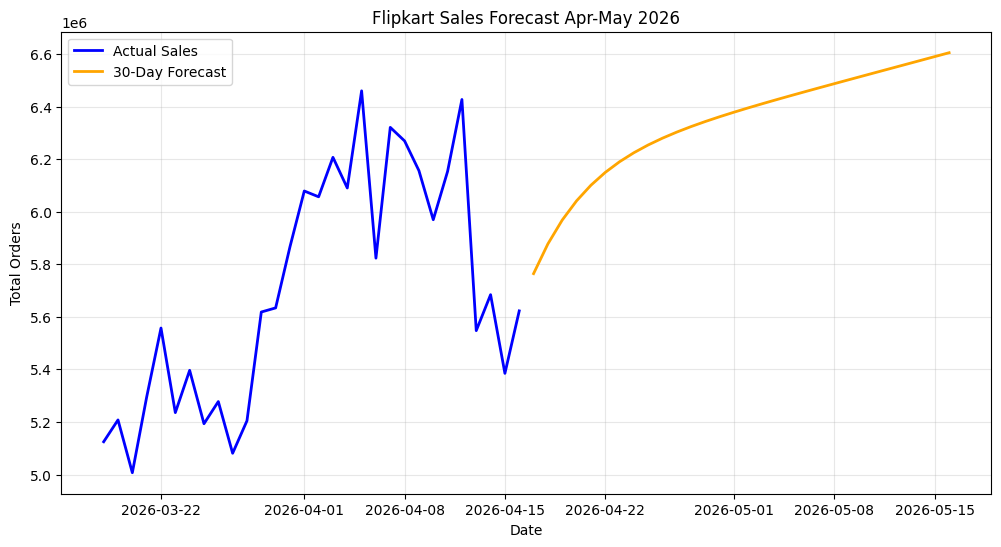

In [68]:
import matplotlib.pyplot as plt 
history = df_clean[['ds', 'total_orders']].tail(30).copy()
history['Type'] = 'Actual'

forecast = future_forecast[['ds', 'Forecast_M']].copy()
forecast['total_orders'] = forecast['Forecast_M']
forecast['Type'] ='Forecast'
plt.figure(figsize=(12,6))
plt.plot(history['ds'], history['total_orders'], label = 'Actual Sales', color='blue', linewidth=2)
plt.plot(forecast['ds'], forecast['total_orders'], label = '30-Day Forecast', color='orange',linewidth=2)
plt.title('Flipkart Sales Forecast Apr-May 2026')
plt.ylabel('Total Orders')
plt.xlabel('Date')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [69]:
AOV = 1200
total_projected_orders = future_forecast['Forecast_M'].sum()
total_revenue_cr = (total_projected_orders * AOV) /10_000_000
print(f"Projected Value for next 30 days:{total_revenue_cr:,.2f}Crores")

Projected Value for next 30 days:22,809.09Crores
